## Initialization

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import importlib

import Dynamics, utilities.mppi, utilities.mpc
importlib.reload(Dynamics)  # ensure latest file version is used
importlib.reload(utilities.mppi)

from Dynamics import jax_dynamics
from utilities.mppi import MPPI

In [ ]:
dt = 0.01
T  = 8.0
ratio_sim_mppi = 5

Q  = jnp.diag(jnp.array([60.0, 2.0, 60.0, 2.0], dtype=jnp.float32))
QT = jnp.diag(jnp.array([140.0, 5.0, 140.0, 5.0], dtype=jnp.float32))
R  = jnp.diag(jnp.array([1e-2, 1e-2], dtype=jnp.float32))
x_ref = jnp.array([0.0, 0.0, 0.0, 0.0], dtype=jnp.float32)

controller = MPPI(
    dyn_fn=jax_dynamics,
    dt=dt, horizon=60, n_samples=2000,
    Q=Q, QT=QT, R=R, x_ref=x_ref,
    noise_scale=jnp.array([4.0, 4.0]), temperature=1.0, seed=0
)
controller.set_sequence(jnp.zeros((60, 2), dtype=jnp.float32))

In [56]:
# Initial state: small perturbation around upright
state = jnp.array([jnp.pi, 0.0, 0.0, 0.0], dtype=jnp.float32)

states = [np.array(state)]
controls = []

for t in np.arange(0.0, T, dt):
    u = controller.step(state)
    # integrate plant faster than control update
    for _ in range(ratio_sim_mppi):
        state = jax_dynamics(state, u, dt=dt/ratio_sim_mppi)
    states.append(np.array(state))
    controls.append(np.array(u))

states = np.array(states)
controls = np.array(controls)

## Demo

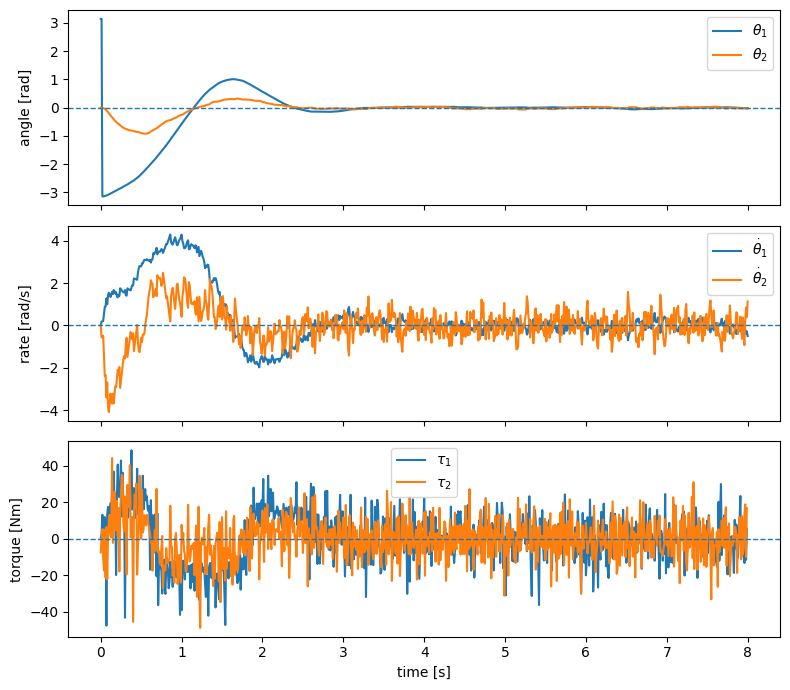

In [55]:
time = np.arange(states.shape[0]) * dt
fig, axs = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

axs[0].plot(time, (states[:, 0] + jnp.pi) % (2*jnp.pi) - jnp.pi, label=r'$\theta_1$')
axs[0].plot(time, (states[:, 2] + jnp.pi) % (2*jnp.pi) - jnp.pi, label=r'$\theta_2$')
axs[0].axhline(0, ls='--', lw=1); axs[0].legend(); axs[0].set_ylabel('angle [rad]')

axs[1].plot(time, states[:, 1], label=r'$\dot{\theta}_1$')
axs[1].plot(time, states[:, 3], label=r'$\dot{\theta}_2$')
axs[1].axhline(0, ls='--', lw=1); axs[1].legend(); axs[1].set_ylabel('rate [rad/s]')

axs[2].plot(time[:-1], controls[:, 0], label=r'$\tau_1$')
axs[2].plot(time[:-1], controls[:, 1], label=r'$\tau_2$')
axs[2].axhline(0, ls='--', lw=1); axs[2].legend(); axs[2].set_ylabel('torque [Nm]'); axs[2].set_xlabel('time [s]')
plt.tight_layout()
plt.show()


## Recurrent Condition Verification

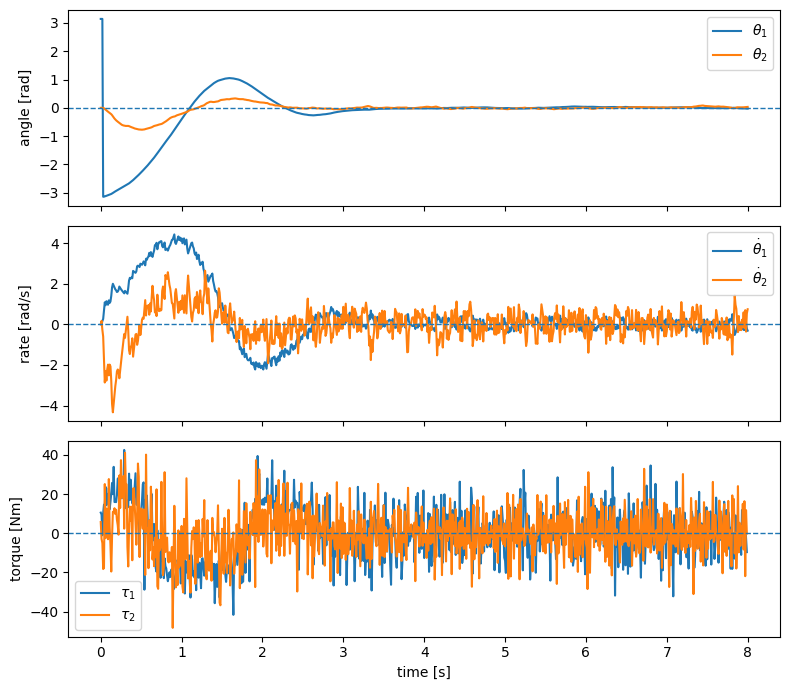